In [17]:
import h5py
import matplotlib.pyplot as plt
import numpy as np

# Load the .mat file using h5py
def load_hdf5_mat_file(file_path):
    try:
        data = h5py.File(file_path, 'r')
        return data
    except Exception as e:
        print(f"Error loading .mat file: {e}")
        return None
    
file_path = r"C:\Users\ChloeAtherton\Capstone\data\NC13.mat"

# Load the file
mat_data = load_hdf5_mat_file(file_path)
hsi_data = np.array(mat_data['HSI'])  # Hyperspectral image data
gt_data = np.array(mat_data['GT']) 


In [8]:
# Explore the structure of the loaded .mat file
def explore_hdf5_structure(data, level=0):
    """Recursively print the structure of an HDF5 file."""
    for key in data.keys():
        print(" " * level + f"{key}: {type(data[key])}")
        if isinstance(data[key], h5py.Group):
            explore_hdf5_structure(data[key], level + 2)

# Inspect the structure
explore_hdf5_structure(mat_data)


GT: <class 'h5py._hl.dataset.Dataset'>
HSI: <class 'h5py._hl.dataset.Dataset'>


Extracted data shape: (270, 808, 1098)


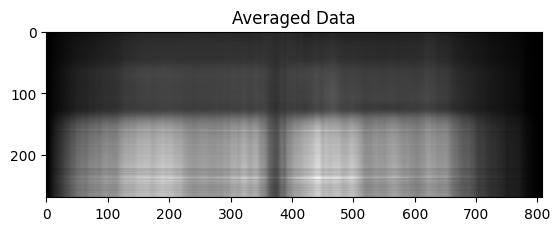

In [11]:
# Replace 'dataset_key' with the key containing your data
dataset_key = 'HSI'
data_array = np.array(mat_data[dataset_key])  # Convert to a NumPy array
print(f"Extracted data shape: {data_array.shape}")

# Display a slice of the data to confirm
averaged_data = np.mean(data_array, axis=2)  # Average along the third dimension
plt.imshow(averaged_data, cmap='gray')
plt.title("Averaged Data")
plt.show()


In [20]:
# Define a modified split function for 3D and 2D data
def split_into_tiles(data, tile_size):
    """
    Splits the input data into smaller tiles of size (tile_size x tile_size).
    
    Args:
        data (np.ndarray): The input 2D or 3D array.
        tile_size (int): Size of the smaller tiles.
    
    Returns:
        list of np.ndarray: List of smaller tiles.
    """
    tiles = []
    if len(data.shape) == 3:  # For 3D data (HSI)
        bands, rows, cols = data.shape
        for i in range(0, rows, tile_size):
            for j in range(0, cols, tile_size):
                tile = data[:, i:i + tile_size, j:j + tile_size]
                if tile.shape[1:] == (tile_size, tile_size):  # Check spatial dimensions
                    tiles.append(tile)
    elif len(data.shape) == 2:  # For 2D data (GT)
        rows, cols = data.shape
        for i in range(0, rows, tile_size):
            for j in range(0, cols, tile_size):
                tile = data[i:i + tile_size, j:j + tile_size]
                if tile.shape == (tile_size, tile_size):  # Check spatial dimensions
                    tiles.append(tile)
    return tiles

# Set tile size
tile_size = 32

#Print shapes to confirm data extraction
print(f"HSI shape: {hsi_data.shape}")
print(f"GT shape: {gt_data.shape}")
# Split HSI and GT into tiles
hsi_tiles = split_into_tiles(hsi_data, tile_size)
gt_tiles = split_into_tiles(gt_data, tile_size)

# Normalize HSI tiles (scale to [0, 1])
hsi_tiles = [tile / np.max(tile) if np.max(tile) > 0 else tile for tile in hsi_tiles]


# Verify number of tiles
print(f"Number of HSI tiles: {len(hsi_tiles)}")
print(f"Number of GT tiles: {len(gt_tiles)}")

# Convert to NumPy arrays for easy indexing
hsi_tiles = np.array(hsi_tiles)
gt_tiles = np.array(gt_tiles)

# Ensure data alignment
assert len(hsi_tiles) == len(gt_tiles), "Mismatch between HSI and GT tile counts!"


HSI shape: (270, 808, 1098)
GT shape: (808, 1098)
Number of HSI tiles: 850
Number of GT tiles: 850


In [23]:
from sklearn.model_selection import train_test_split

# Split into train and test sets (80% train, 20% test)
hsi_train, hsi_test, gt_train, gt_test = train_test_split(
    hsi_tiles, gt_tiles, test_size=0.2, random_state=42
)

print(f"Train set: {len(hsi_train)} samples")
print(f"Test set: {len(hsi_test)} samples")


Train set: 680 samples
Test set: 170 samples


In [41]:
import torch
import torch.nn as nn

import torch
import torch.nn as nn

class UNet(nn.Module):
    def __init__(self, in_channels=270, num_classes=14):
        super(UNet, self).__init__()
        self.num_classes = num_classes
        
        # Encoder
        def conv_block(in_channels, out_channels):
            return nn.Sequential(
                nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1),
                nn.ReLU(inplace=True),
                nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1),
                nn.ReLU(inplace=True)
            )

        self.enc1 = conv_block(in_channels, 64)
        self.enc2 = conv_block(64, 128)
        self.enc3 = conv_block(128, 256)
        self.pool = nn.MaxPool2d(2)

        # Decoder
        self.up3 = nn.ConvTranspose2d(256, 128, kernel_size=2, stride=2)
        self.dec3 = conv_block(256, 128)  # 128 from upsampling + 128 from skip connection
        self.up2 = nn.ConvTranspose2d(128, 64, kernel_size=2, stride=2)
        self.dec2 = conv_block(128, 64)  # 64 from upsampling + 64 from skip connection
        
        self.final = nn.Conv2d(64, num_classes, kernel_size=1)

    def forward(self, x):
        # Encoder
        enc1 = self.enc1(x)  # [batch_size, 64, H, W]
        enc2 = self.enc2(self.pool(enc1))  # [batch_size, 128, H/2, W/2]
        enc3 = self.enc3(self.pool(enc2))  # [batch_size, 256, H/4, W/4]
        
        # Decoder
        dec3 = self.dec3(torch.cat([self.up3(enc3), enc2], dim=1))  # [batch_size, 128, H/2, W/2]
        dec2 = self.dec2(torch.cat([self.up2(dec3), enc1], dim=1))  # [batch_size, 64, H, W]
        return self.final(dec2)  # [batch_size, num_classes, H, W]


In [25]:
from torch.utils.data import Dataset, DataLoader

class HyperspectralDataset(Dataset):
    def __init__(self, images, masks):
        self.images = images  # Hyperspectral tiles of shape (270, 32, 32)
        self.masks = masks    # Ground truth tiles of shape (32, 32)

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        image = torch.tensor(self.images[idx], dtype=torch.float32)  # (270, 32, 32)
        mask = torch.tensor(self.masks[idx], dtype=torch.long)      # (32, 32)
        return image, mask

# Split into training and testing
train_dataset = HyperspectralDataset(hsi_train, gt_train)
test_dataset = HyperspectralDataset(hsi_test, gt_test)

train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=8, shuffle=False)


In [36]:
import torch
print(f"Is CUDA available: {torch.cuda.is_available()}")
print(f"PyTorch version: {torch.__version__}")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

unique_classes = torch.unique(torch.tensor(gt_tiles))
print(f"Unique classes in masks: {unique_classes}")
print(f"Number of classes: {len(unique_classes)}")


Is CUDA available: False
PyTorch version: 2.5.1+cpu
Using device: cpu
Unique classes in masks: tensor([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13],
       dtype=torch.uint8)
Number of classes: 14


In [ ]:
import matplotlib.pyplot as plt
import torch

def train_and_validate_model(model, train_loader, test_loader, criterion, optimizer, num_epochs=10):
    model.train()  # Set the model to training mode

    # Store losses for plotting
    train_losses = []
    val_losses = []

    for epoch in range(num_epochs):
        running_train_loss = 0.0
        model.train()  # Set the model to training mode

        # Training loop
        for images, masks in train_loader:
            # Move data to the appropriate device
            images, masks = images.to(device), masks.to(device)

            # Zero the gradients
            optimizer.zero_grad()

            # Forward pass
            outputs = model(images)  # Output: (batch_size, num_classes, H, W)

            # Compute loss
            loss = criterion(outputs, masks)
            running_train_loss += loss.item()

            # Backward pass and optimization
            loss.backward()
            optimizer.step()

        # Calculate average training loss for this epoch
        avg_train_loss = running_train_loss / len(train_loader)
        train_losses.append(avg_train_loss)

        # Validation loop
        running_val_loss = 0.0
        model.eval()  # Set the model to evaluation mode
        with torch.no_grad():
            for images, masks in test_loader:
                # Move data to the appropriate device
                images, masks = images.to(device), masks.to(device)

                # Forward pass
                outputs = model(images)
                loss = criterion(outputs, masks)
                running_val_loss += loss.item()

        # Calculate average validation loss for this epoch
        avg_val_loss = running_val_loss / len(test_loader)
        val_losses.append(avg_val_loss)

        print(f"Epoch {epoch+1}/{num_epochs}, Training Loss: {avg_train_loss:.4f}, Validation Loss: {avg_val_loss:.4f}")

    # Plot the losses
    plt.figure(figsize=(10, 5))
    plt.plot(range(1, num_epochs + 1), train_losses, label='Training Loss')
    plt.plot(range(1, num_epochs + 1), val_losses, label='Validation Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('Training and Validation Loss')
    plt.legend()
    plt.grid()
    plt.show()

    return train_losses, val_losses

# Train and validate the model
train_losses, val_losses = train_and_validate_model(model, train_loader, test_loader, criterion, optimizer, num_epochs=30)



Epoch 1/30, Training Loss: 0.8168, Validation Loss: 0.8274
Epoch 2/30, Training Loss: 0.8079, Validation Loss: 0.8021
Epoch 3/30, Training Loss: 0.7903, Validation Loss: 0.8147
Epoch 4/30, Training Loss: 0.7998, Validation Loss: 0.7904


In [ ]:
def evaluate_model(model, dataloader, criterion):
    model.eval()  # Set the model to evaluation mode
    total_loss = 0.0
    total_correct = 0
    total_pixels = 0
    iou_scores = []
    dice_scores = []

    with torch.no_grad():  # Disable gradient computation
        for images, masks in dataloader:
            # Move data to the appropriate device
            images, masks = images.to(device), masks.to(device)

            # Forward pass
            outputs = model(images)  # (batch_size, num_classes, height, width)
            preds = torch.argmax(outputs, dim=1)  # Predicted class for each pixel

            # Compute loss
            loss = criterion(outputs, masks)
            total_loss += loss.item()

            # Compute pixel-wise accuracy
            total_correct += (preds == masks).sum().item()
            total_pixels += masks.numel()

            # Compute IoU and Dice scores for each batch
            for class_idx in range(model.num_classes):
                pred_mask = (preds == class_idx)
                true_mask = (masks == class_idx)

                intersection = (pred_mask & true_mask).sum().item()
                union = (pred_mask | true_mask).sum().item()
                dice = 2 * intersection / (pred_mask.sum().item() + true_mask.sum().item() + 1e-6)

                if union > 0:
                    iou_scores.append(intersection / union)
                dice_scores.append(dice)

    # Compute average metrics
    print('Total Pixels': total_pixels)
    pixel_accuracy = total_correct / total_pixels
    mean_iou = sum(iou_scores) / len(iou_scores)
    mean_dice = sum(dice_scores) / len(dice_scores)

    print(f"Validation Loss: {total_loss / len(dataloader):.4f}")
    print(f"Pixel Accuracy: {pixel_accuracy:.4f}")
    print(f"Mean IoU: {mean_iou:.4f}")
    print(f"Mean Dice Score: {mean_dice:.4f}")

    return pixel_accuracy, mean_iou, mean_dice


In [45]:
# Evaluate the model on the test set
pixel_accuracy, mean_iou, mean_dice = evaluate_model(model, test_loader, criterion)


Validation Loss: 0.8684
Pixel Accuracy: 0.7141
Mean IoU: 0.2376
Mean Dice Score: 0.1098


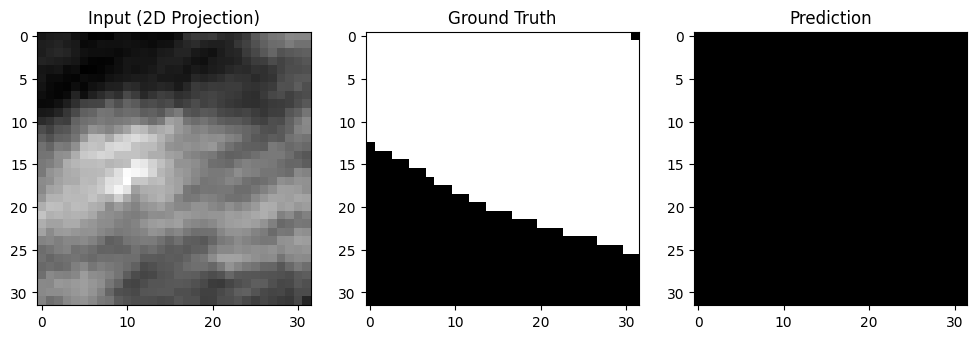

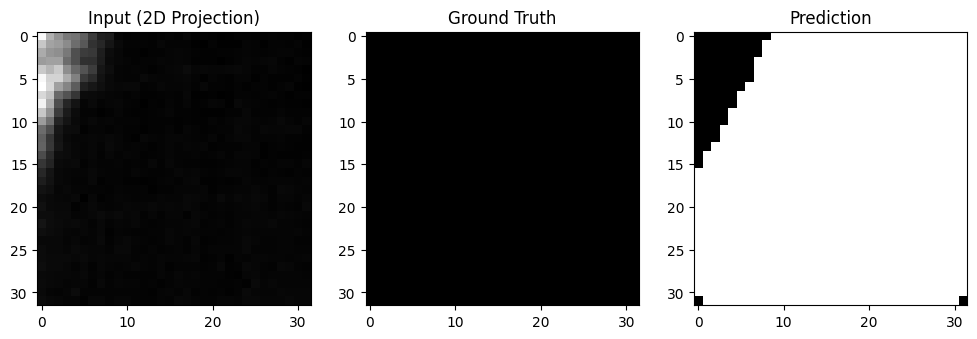

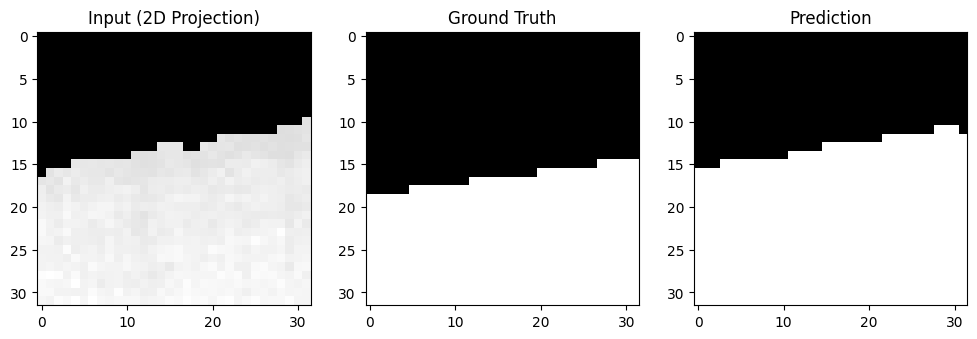

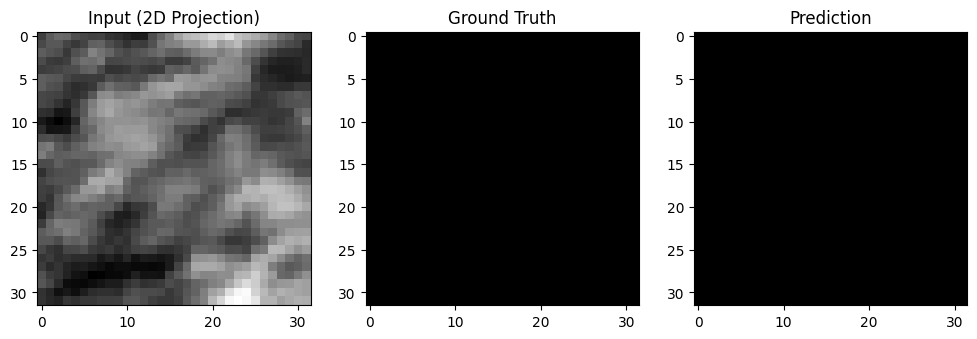

In [46]:
import matplotlib.pyplot as plt

def visualize_predictions_2d(model, dataloader):
    model.eval()
    images, masks = next(iter(dataloader))  # Get a single batch
    images, masks = images.to(device), masks.to(device)

    with torch.no_grad():
        outputs = model(images)
        preds = torch.argmax(outputs, dim=1)

    # Display predictions
    for i in range(min(4, len(images))):  # Show up to 4 examples
        plt.figure(figsize=(12, 4))

        # Collapse hyperspectral input to 2D by averaging across bands
        input_2d = images[i].mean(dim=0).cpu()  # Mean across channels

        plt.subplot(1, 3, 1)
        plt.title("Input (2D Projection)")
        plt.imshow(input_2d, cmap='gray')  # Projected to 2D

        plt.subplot(1, 3, 2)
        plt.title("Ground Truth")
        plt.imshow(masks[i].cpu(), cmap='gray')

        plt.subplot(1, 3, 3)
        plt.title("Prediction")
        plt.imshow(preds[i].cpu(), cmap='gray')

        plt.show()

# Visualize predictions
visualize_predictions_2d(model, test_loader)
